# Project A1: Exploring Cook County Housing

<hr style="border: 1px solid #fdb515;" />
<hr style="border: 5px solid #003262;" />
<br/><br/>

## Introduction

This project explores what can be learned from an extensive housing dataset that is embedded in a dense social context in Cook County, Illinois.

In Project A1, the notebook will cover some basic Exploratory Data Analysis (EDA) to understand the structure of the data. Next, we will be adding a few new features to the dataset, while cleaning the data as well in the process. Lastly, we'll design custom error metric to replace RMSE in this setting.

In Project A2 (the following assignment), we will specify and fit a linear model for the purpose of prediction. Finally, we will analyze the model's error, brainstorm ways to improve its performance, and test the custom error metric defined in Project A1.


In [16]:
import numpy as np

import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

import zipfile
import os

# Plot settings
plt.rcParams['figure.figsize'] = (12, 9)
plt.rcParams['font.size'] = 12

<br/><br/>
<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

# The Data

The dataset consists of over 500,000 records from Cook County, Illinois, the county where Chicago is located. The dataset has 61 features in total; the 62nd is `Sale Price`, which we will predict with linear regression in the next part of this project. An explanation of each variable can be found in the included `codebook.txt` file (can be optionally opened by first clicking the `data` folder, then clicking `codebook.txt` file in the navigation pane). Some of the columns have been filtered out to ensure this notebook doesn't become overly long when dealing with data cleaning and formatting.

The data are split into training and test sets with 204,792 and 68,264 observations, respectively, but we will only be working on the training set for this part of the project.

Let's first extract the data from the `cook_county_data.zip`. Notice we didn't leave the `csv` files directly in the directory because they take up too much space without some prior compression. Just run the cells below to load in the initial data: 

In [17]:
with zipfile.ZipFile('data/cook_county_data.zip') as item:
    with item.open("cook_county_train.csv") as f:
        initial_data = pd.read_csv(f, index_col='Unnamed: 0')

Let's load the initial data.

As a good sanity check, we should at least verify that the data shape matches the description.

In [18]:
# 204,792 observations and 62 features in training data
assert initial_data.shape == (204792, 62)
# Sale Price is provided in the training data
assert 'Sale Price' in initial_data.columns.values

The next order of business is getting a feel for the variables in our data.  A more detailed description of each variable is included in `codebook.txt` (in the same directory as this notebook). 

Let's take a quick look at all the current columns in the initial data.

In [19]:
initial_data.columns.values

<StringArray>
[                       'PIN',             'Property Class',
          'Neighborhood Code',           'Land Square Feet',
                  'Town Code',                 'Apartments',
              'Wall Material',              'Roof Material',
                   'Basement',            'Basement Finish',
            'Central Heating',              'Other Heating',
                'Central Air',                 'Fireplaces',
                 'Attic Type',               'Attic Finish',
                'Design Plan',          'Cathedral Ceiling',
       'Construction Quality',          'Site Desirability',
              'Garage 1 Size',          'Garage 1 Material',
        'Garage 1 Attachment',              'Garage 1 Area',
              'Garage 2 Size',          'Garage 2 Material',
        'Garage 2 Attachment',              'Garage 2 Area',
                      'Porch',         'Other Improvements',
       'Building Square Feet',           'Repair Condition',
          

In [20]:
initial_data['Description'][0]

'This property, sold on 09/14/2015, is a one-story houeshold located at 2950 S LYMAN ST.It has a total of 6 rooms, 3 of which are bedrooms, and 1.0 of which are bathrooms.'

<br/><br/>
<hr style="border: 1px solid #fdb515;" />

# Part 1: Contextualizing the Data
Let's explore socially context before diving into a full-scale analysis

<!-- BEGIN QUESTION -->

<br><br>

---

## Granularity of the Dataset

Based on the columns in this dataset and the values that they take, we can infer what each row represents.

Each row represents a property assessment for a unique property. It's not PIN, as same property can be assessed multiple time throughout some years

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br><br>

---
## Purpose of the Data Collection

The underlying problem:
- The data was collected by the CCAO. It has a mandate to assess the value of all commercial and residential property values every three years in order to determine property taxes.
- But more fundamental reason that led CCAO to make this data public is due to a tax scandal. The Chicago Tribune uncovered a major scandal in the property management system ran by CCAO, where the corruption and systematic bias led to highly regressive tax system burdening more on the poor homeowners.(The simple linear model tends to overvalue the cheaper houses and devalue more expensive houses). 
- Additionally, in large part, one of the main origins of the problem was because of an institutional structure of the property assessment where the higher income and whiter region disproportionately abuses the tax appeal to lower the total tax value, while the oppposites fails to do so.

The fix:
- The data was collected to make a more fair tax system that resolves the problem where the rich people disproportionately benefit from the tax-assessment and result in unfair regression system that disbenefit the poor. 
- So the purpose of collecting the data was to build a ***transparent, accurate (uniform & impartial), fair** model that predicts the housing price, leading to distributional equity in property taxation by maintaining flat tax rate and regain the once lost public trust.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br><br>

---
## Outline Analytical Questions

Before doing any EDA, let's create few questions about housing and plan what analytical tool to be used to answer them.

> What is relationship between the property size and sales price? Create a scatterplot between the column "Land Square Feet" and "Sale Price."

> Is there any patterns in price prediction based on the underlying demographics? Create a scatterplot between "Land Square Feet" and "Sale Price" for each demographics. It might require additional dataset on demographics such as race, income. Compare the difference in slopes, observing which demographics has stronger relationship between the property size and price.

> Is there any difference in the distrbution of sales price based on the neighborhood code? Some region might have be populated with richer and whiter demographics, which can potentially affect housing price. Create a histogram plot of "Sale Price" for each grouped "Neigborhood Code (mapping)"

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br><br>

---
## Additional Analytical Questions

Suppose now, in addition to the information already contained in the dataset, we also have access to several new columns containing demographic data about the owner, including race/ethnicity, gender, age, annual income, and occupation. Provide one new question about housing in Cook County that can be answered using at least one column of demographic data and at least one column of existing data.

> Based on annual income, is there any meaningul difference in how the sale price ("Sale Price") relates to property size ("Land Square Feet")?

First option:
- Compute the ratio (price per sq. ft) = (Sale Price) / (Land Square Feet) for each property, and then create hisogram of this ratio for different income (high, low, middle). 
- This give insights on how property value per unit area differs across income

Second option: 
- Divide dataset into low income and middle-high income. 
- Then create hexplot of Sale Price and Land Square Feet for each income group. 
- By looking at density, we can identify which regions of "prices per size" the higher income owners tend to have.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br><br>

---
## Explore Unique Regional Features

Look at `codebook.txt` to see some of the unique regional features CCAO utilizes, such as `O’Hare Noise`. Now imagine we were in charge of predicting the `Sale Price` of houses in **our hometown** (actual real life hometown/city - not the data provided). Propose a feature to collect specific to our location and hypothesize why it might be useful in predicting the sale price of houses.

- A large proportion of the house at Berkeley region is accounted by students. So many residents would've considered distance to the UC Berkeley campus as a key factor in determining if the price is reasonable or not. So the proximity to UC Berkeley campus is useful to predict the sale price.

- In contrast, most of the residents in my Korean hometown are family with children, rather than singles. And Korea has a very high emphasis in education, and parents are willing to move into places with education environment over their job. (Rather take a public transportation or drive to work than giving up education). This culture and the demographics of my hometown makes the proximity to elementary, middle school important in predicting the housing price.

<!-- END QUESTION -->

<br/><br/>
<hr style="border: 1px solid #fdb515;" />

# Part 2: Exploratory Data Analysis

This dataset was collected by the [Cook County Assessor's Office](https://datacatalog.cookcountyil.gov/Property-Taxation/Archive-Cook-County-Assessor-s-Residential-Sales-D/5pge-nu6u) in order to build a model to predict the monetary value of a home. More about data collection in the CCAO’s [Residential Data Integrity Preliminary Report](https://gitlab.com/ccao-data-science---modeling/ccao_sf_cama_dev/-/blob/master/documentation/Preliminary%20Report%20on%20Data%20Integrity%20June%207,%202019.pdf). In Project A2, we will be building a linear regression model that predicts sales prices using training data, but it's important to first understand how the structure of the data informs such a model. In this section, we will make a series of exploratory visualizations and feature engineering in preparation for that prediction task.

Note that we will perform EDA on the **initial data**.

### Sale Price
We begin by examining the distribution of our target variable `Sale Price`. The following helper method `plot_distribution` can be used to visualize the distribution of the `Sale Price` using both the histogram and the box plot at the same time. 

In [21]:
def plot_distribution(data, label):
    fig, axs = plt.subplots(nrows=2)

    sns.distplot(
        data[label], 
        ax=axs[0]
    )
    sns.boxplot(
        x=data[label],
        width=0.3, 
        ax=axs[1],
        showfliers=False,
    )

    # Align axes
    spacer = np.max(data[label]) * 0.05
    xmin = np.min(data[label]) - spacer
    xmax = np.max(data[label]) + spacer
    axs[0].set_xlim((xmin, xmax))
    axs[1].set_xlim((xmin, xmax))

    # Remove some axis text
    axs[0].xaxis.set_visible(False)
    axs[0].yaxis.set_visible(False)
    axs[1].yaxis.set_visible(False)

    # Put the two plots together
    plt.subplots_adjust(hspace=0)
    fig.suptitle("Distribution of " + label)

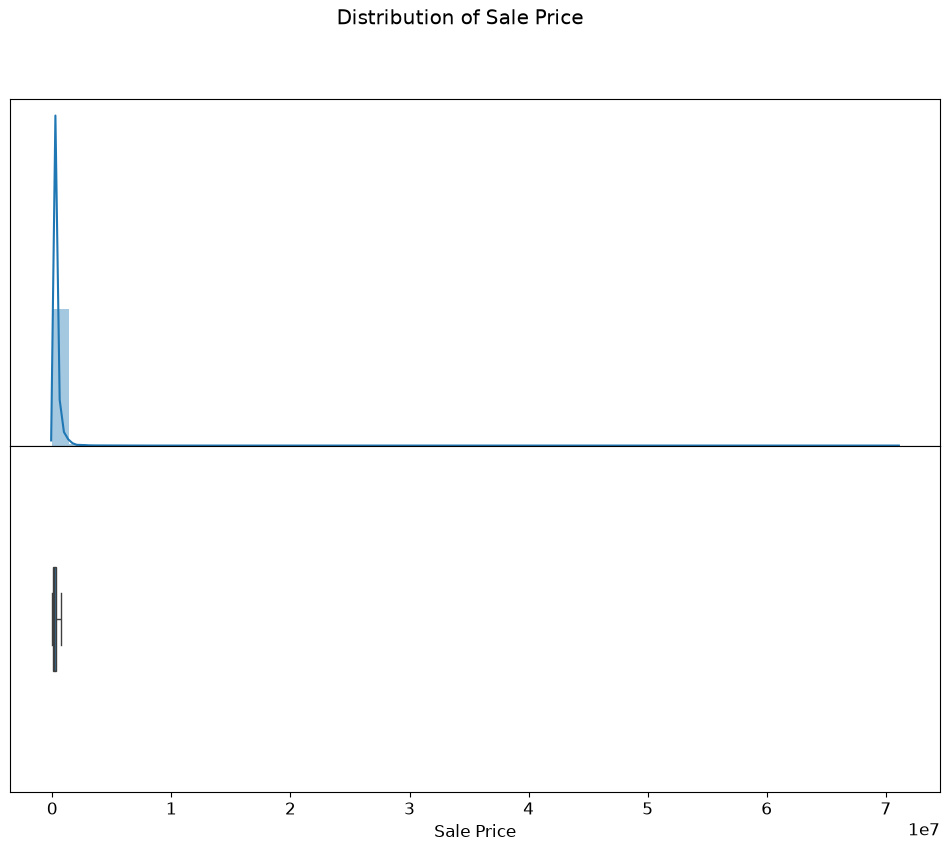

In [22]:
plot_distribution(initial_data, label='Sale Price')

We can see that the data is highly skewed to the right currently, probably because of some extremely expensive houses. To get a clearer view of the distribution, run the following cell to examine a more limited range of house prices from [\\$0, \\$1,000,000]. 

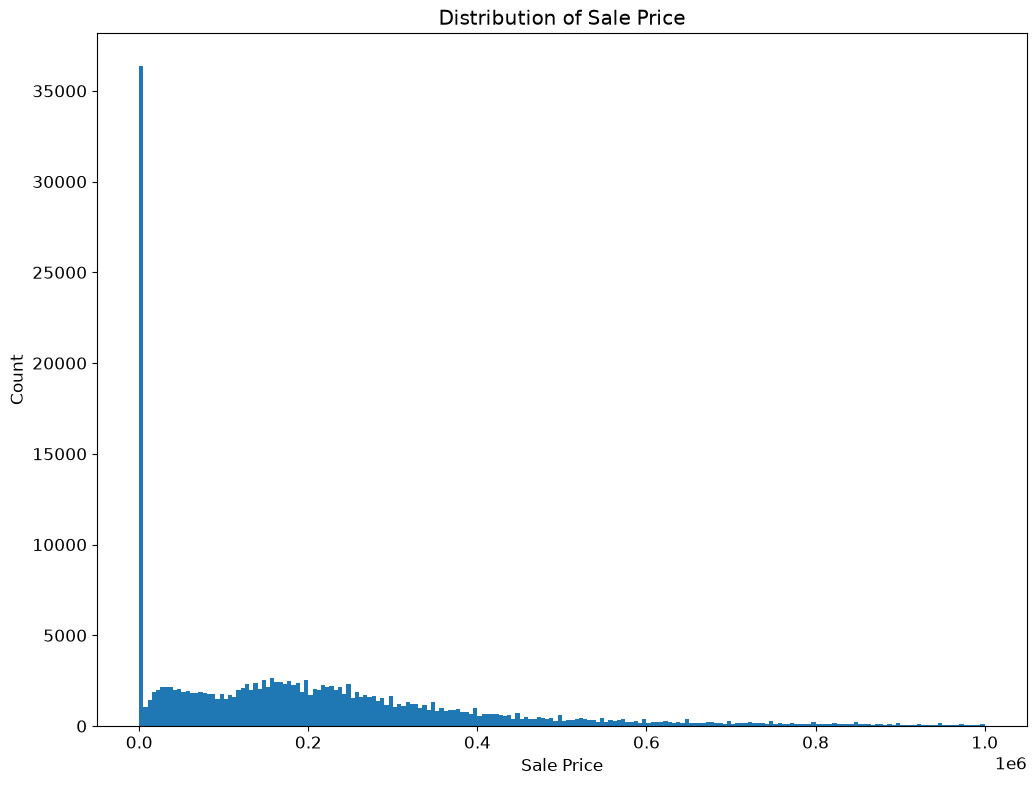

In [23]:
no_right_outliers = initial_data[initial_data['Sale Price'] <= 1000000]['Sale Price']
plt.hist(no_right_outliers, bins=200)
plt.xlabel("Sale Price")
plt.ylabel("Count")
plt.title("Distribution of Sale Price")
plt.show()

Interestingly, we also see this spike near in the smallest bin of our `Sale Price` distribution, something that wasn't immediately evident from our initial plot. Run the following cell to see which values are the most common.

In [24]:
initial_data['Sale Price'].value_counts()

Sale Price
1         35546
250000     1252
200000     1232
150000     1189
175000     1118
          ...  
452484        1
37358         1
134134        1
25515         1
142515        1
Name: count, Length: 14720, dtype: int64

This should be immediately concerning. While we don't know the exact reason why so many houses were reported as \\$1 (most likely a placeholder value of some sort), including these data points in any model would heavily skew the fit. After all, most houses are worth more than \\$1!

<br><br>

---
## Examine Small Valued Sale Prices

The findings with the \\$1 entries indicates something interesting may be happening with small valued `Sale Price`s. Let's find a **list** of the **top 4 most** common `Sale Price`s within the range of [\\$0, \\$500).

In [25]:
top_sales_to_500 = initial_data[(initial_data["Sale Price"] < 500) & (initial_data["Sale Price"] >= 0)]["Sale Price"].value_counts().index
q2a = top_sales_to_500[:4].tolist()

This exploration has indicated to us that moving forward we should probably pick a cutoff to get rid of smaller, probably unrepresentative `Sale Price`s. As a result, moving forward we'll only look at households whose price is at least \\$500 dollars. While this cutoff is slightly arbitrary, this decision was made to address these unrealistically low values. 

On the other hand, there are also the upper-bound outliers that skewed our data in the first place. Let's find the proportion of how many buildings sold for over \\$1,000,000.

In [26]:
len(initial_data[initial_data['Sale Price'] > 1000000]) / len(initial_data[initial_data['Sale Price'] >= 500])

0.034114520129520334

Since there's only around 3% (or 5,000) buildings that have sold over \\$1,000,000 it would definitely be reasonable to build a model for the [\\$500, \\$1,000,000] range. For ProjA1 though, we're going to try and build a model to handle the entire range from [\\$500, infinity). As a result, we will need to reason with how the outliers shape the distribution of points. One way we can make our initial visualization more legible is by log-transforming our data to neutralize the impact of the right outliers.

<br><br>

---
## Setting Up Training Data

As previously established to zoom in on the visualization of most households, we will focus only on a subset of `Sale Price` for this notebook. In addition, it may be a good idea to apply a log transformation to `Sale Price`. Assign `training_data` to a new `DataFrame` that is the same as `initial_data` **except with the following changes**:

- `training_data` should contain only households whose price is at least $500.
- `training_data` should contain a new `Log Sale Price` column that contains the log-transformed sale prices.

It's important to keep the original column `Sale Price` unmodified as it will be helpful for later analysis.

**Note**: This also implies from now on, the target variable in the model will be the log-transformed sale prices from the column `Log Sale Price`. 

In [27]:
training_data = initial_data[initial_data["Sale Price"] >= 500]
training_data["Log Sale Price"] = training_data["Sale Price"].apply(np.log)

Let's create a new distribution plot using the log-transformed sale prices. The distribution for `Log Scale Price` is relatively more normal.

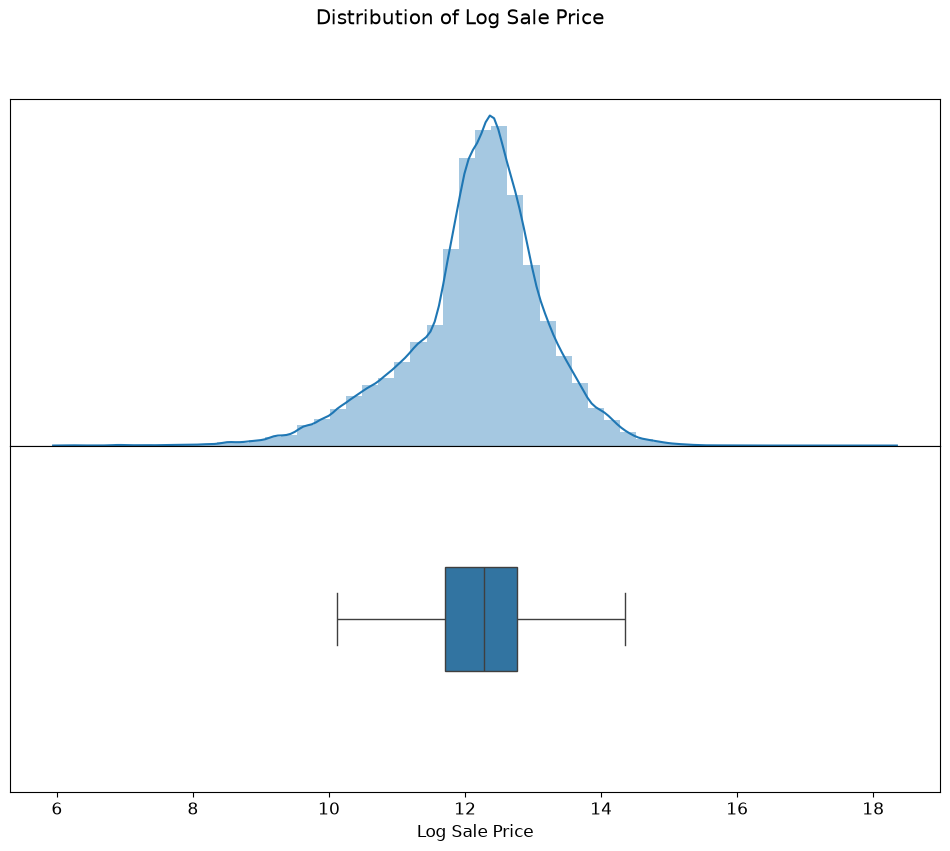

In [28]:
plot_distribution(training_data, label='Log Sale Price');

<br><br>

---
## Correlation Between Log Sale Price and Features

Next, we want to explore if there is any correlation between `Log Sale Price` and the total area occupied by the property. The `codebook.txt` file tells us the column `Building Square Feet` should do the trick — it measures "(from the exterior) the total area, in square feet, occupied by the building".

Let's also apply a log transformation to the `Building Square Feet` column.

In the following cell, create a new column `Log Building Square Feet` in our `training_data` that contains the log-transformed area occupied by each property. 

**You should NOT remove or modify the original `Building Square Feet` column as it will be used for later questions**. If you accidentally remove it, just restart your kernel and run the cells again.

*To ensure that any errors from this part do not propagate to later questions, there will be no hidden tests for this question.*

In [29]:
training_data['Log Building Square Feet'] = training_data["Building Square Feet"].apply(np.log)

<!-- BEGIN QUESTION -->

<br><br>

---
## Visualizing Correlation of Log Sales Price with Log Property Size

In the visualization below, we created a `jointplot` with `Log Building Square Feet` on the x-axis, and `Log Sale Price` on the y-axis. In addition, we fit a simple linear regression line through the bivariate scatter plot in the middle.

Based on the following plot, would `Log Building Square Feet` make a good candidate as one of the features for our model? Why or why not?

![Joint Plot](images/q2p3_jointplot.png)


Good feature is one that show a linear relationship with the transformed or non-transformed target variable, so that we can create a linear model. The log building square feet shows roughly positive linear relationship with log sale price, making it a decently good feature. However, there is a more variance in log sale price for lower end, and variance decrease for larger log building square feet value. This suggests log building sqaure feet feature is decent, but it doesn't by alone explain the log sale price.

<!-- END QUESTION -->

<br><br>

---
## Adjusting for Outliers

Continuing from the previous part, there might be more outliers that prevent from creating a clear visualization or capturing the trend of the majority of the houses. 

The helper function `remove_outliers` removes outliers from the dataset based on a threshold value of a variable. For example, `remove_outliers(training_data, 'Building Square Feet', lower=500, upper=8000)` should return a copy of `data` with only observations that satisfy `Building Square Feet` less than 8000 (exclusive) and `Building Square Feet` greater than 500 (exclusive).

In [30]:
def remove_outliers(data, variable, lower=-np.inf, upper=np.inf):
    """
    Input:
      data (DataFrame): the table to be filtered
      variable (string): the column with numerical outliers
      lower (numeric): observations with values lower than or equal to this will be removed
      upper (numeric): observations with values higher than or equal to this will be removed
    
    Output:
      a DataFrame with outliers removed
      
    Note: This function should not change or mutate the contents of data.
    """  
    return data[(data[variable] > lower) & (data[variable] < upper)] 

<br><br>

To give an example on how `remove_outliers` might be useful in the future, plot the distribution of the attribute `Estimate (Land)` below using `plot_distribution` with the provided code below. From `codebook.txt`, `Estimate (Land)` estimates the market value of a property’s land from the prior tax year. 

From the visualization, we can observed that: 

“At least 95% of the properties in `training_data` have `Estimate (Land)` values less than $500,000.00”

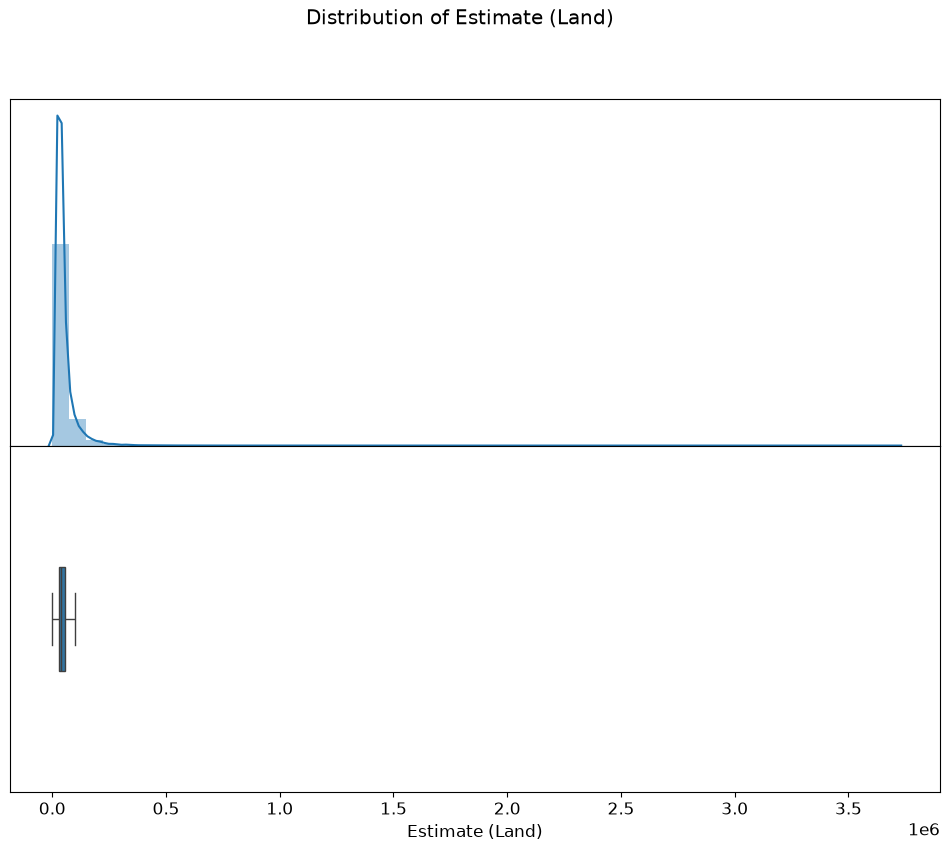

In [31]:
# Run this to see the distribution!
plot_distribution(training_data, label='Estimate (Land)');

<br><br>

---
## Example: Remove Outliers for Estimate (land)

Similar to the exploration of `Sale Price`, we may have observed that `Estimate (Land)` contains some points that heavily skew its distribution. One way to address these issues is to transform the data to a different scale, as we did with `Sale Price`. Another way is to remove outliers. 

In this subpart, we define an outlier as any point that is 1.5 interquartile ranges above Q3 or below Q1 (exclusive of the boundary). Assign `IQR` to the interquartile range of `Estimate (Land)`. Then, assign `q4c_training_data` to `training_data` with only rows which are not considered `Estimate (Land)` outliers using `remove_outliers`.

More on how IQR works [Wikipedia page](https://en.wikipedia.org/wiki/Interquartile_range).

In [32]:
Q3 = training_data["Estimate (Land)"].quantile(q=0.75)
Q1 = training_data["Estimate (Land)"].quantile(q=0.25)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
q4c_training_data = remove_outliers(training_data, "Estimate (Land)", lower_bound, upper_bound)

Let's create a new distribution plot using the `Estimate (Land)` with outliers removed. We can observe that the distribution for `Estimate (Land)` is much less skewed with `q4c_training_data`!

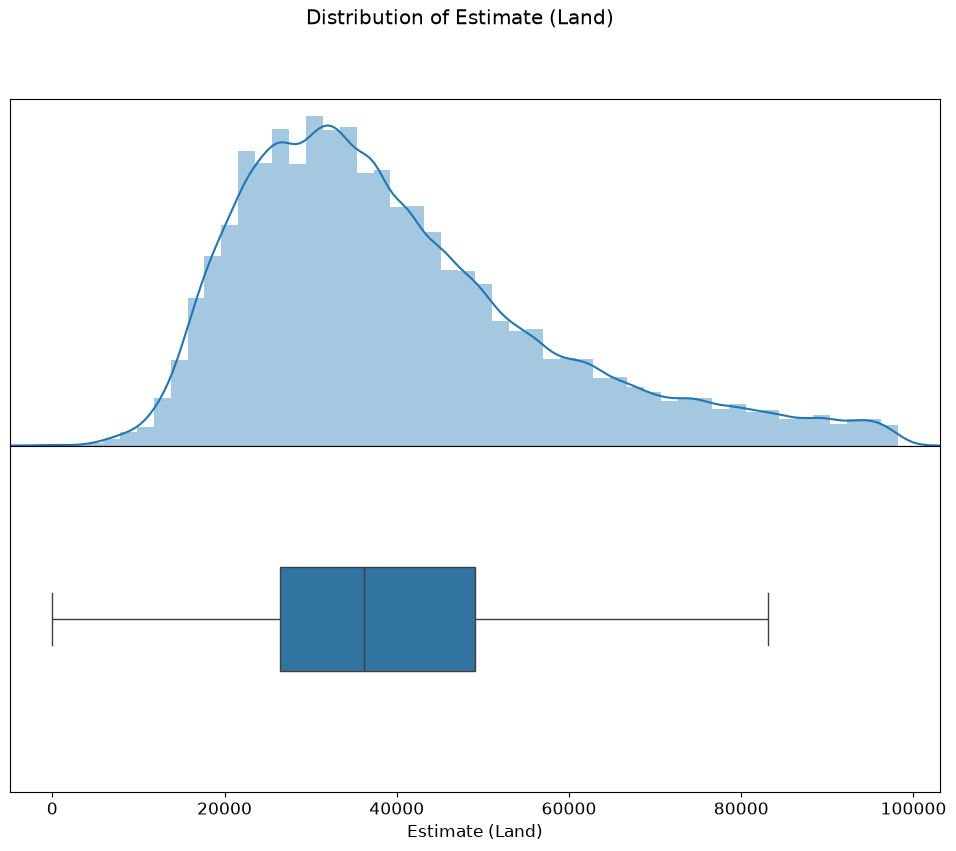

In [33]:
plot_distribution(q4c_training_data, label='Estimate (Land)');

<br/><br/>
<hr style="border: 1px solid #fdb515;" />

# Part 3: Feature Engineering

### Bathrooms

Let's start simple by extracting the total number of bathrooms as the first feature for the model. The `Bathrooms` column doesn't actually exist in the original `DataFrame`. Instead, it is part of the `Description` column.

<br><br>

---
## Manual Examination on Description Feature

Let's take a closer look at the `Description` column first. Compare the description for a few rows. 

We can observe that the following list of variables can be extracted from the `Description` column.

1. The date the property was sold on.
2. The number of stories the property contains.
3. The address of the property.
4. The total number of rooms inside the property.
5. The total number of bedrooms inside the property.
6. The total number of bathrooms inside the property.

In [34]:
training_data["Description"].iloc[0]

'This property, sold on 05/23/2018, is a one-story houeshold located at 2844 N LOWELL AVE.It has a total of 6 rooms, 3 of which are bedrooms, and 1.0 of which are bathrooms.'

<br><br>

---
## Create the Number of Bathrooms Feature

The helper function `add_number_bathrooms(data)` returns a copy of `data` with an additional column called `Bathrooms` that contains the total number of bathrooms (**as floats**) for each house. Treat missing values as zeros, if necessary.

**Note**: From inspecting the `Description` column, we reconized the general structure within the text related to bathroom: "and __ of which are bathrooms." Use RegEx to capture this pattern!

In [35]:
def add_total_bathrooms(data):
    """
    Input:
      data (DataFrame): a DataFrame containing at least the Description column.

    Output:
      a Dataframe with a new column "Bathrooms" containing floats.

    """
    with_rooms = data.copy()
    with_rooms["Bathrooms"] = (with_rooms["Description"]
                               .str.extract(r'and\s(\d+\.\d+) of which are bathrooms')
                               .astype(float)
                              .fillna(0))
    
    return with_rooms

training_data = add_total_bathrooms(training_data)
training_data

,PIN,Property Class,Neighborhood Code,Land Square Feet,Town Code,Apartments,Wall Material,Roof Material,Basement,Basement Finish,...,Age Decade,Pure Market Filter,Garage Indicator,Neigborhood Code (mapping),Town and Neighborhood,Description,Lot Size,Log Sale Price,Log Building Square Feet,Bathrooms
1,13272240180000,202,120,3780.0,71,0.0,2.0,1.0,1.0,1.0,...,9.6,1,1.0,120,71120,"This property, sold on 05/23/2018, is a one-st...",3780.0,12.560244,6.904751,1.0
2,25221150230000,202,210,4375.0,70,0.0,2.0,1.0,2.0,3.0,...,11.2,1,1.0,210,70210,"This property, sold on 02/18/2016, is a one-st...",4375.0,9.998798,6.810142,1.0
3,10251130030000,203,220,4375.0,17,0.0,3.0,1.0,1.0,3.0,...,6.3,1,1.0,220,17220,"This property, sold on 07/23/2013, is a one-st...",4375.0,12.323856,7.068172,1.5
4,31361040550000,202,120,8400.0,32,0.0,3.0,1.0,2.0,3.0,...,6.3,1,1.0,120,32120,"This property, sold on 06/10/2016, is a one-st...",8400.0,10.025705,6.855409,1.0
6,30314240080000,203,181,10890.0,37,0.0,1.0,1.0,1.0,3.0,...,10.9,1,1.0,181,37181,"This property, sold on 10/26/2017, is a one-st...",10890.0,11.512925,7.458186,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204787,25163010260000,202,321,4375.0,72,0.0,2.0,1.0,1.0,1.0,...,5.8,1,1.0,321,72321,"This property, sold on 07/23/2014, is a one-st...",4375.0,10.521372,6.813445,1.0
204788,5063010090000,204,21,16509.0,23,0.0,1.0,1.0,1.0,1.0,...,9.3,1,1.0,21,2321,"This property, sold on 03/27/2019, is a one-st...",16509.0,12.323856,7.603399,1.5
204789,16333020150000,202,90,3810.0,15,0.0,2.0,1.0,1.0,1.0,...,5.9,1,1.0,90,1590,"This property, sold on 01/31/2014, is a one-st...",3810.0,11.813030,6.815640,2.0
204790,9242030500000,203,80,6650.0,22,0.0,2.0,1.0,1.0,3.0,...,6.0,1,1.0,80,2280,"This property, sold on 02/22/2018, is a one-st...",6650.0,12.879017,7.092574,1.0


<!-- BEGIN QUESTION -->

<br><br>

---
## Verify Association Between Bathrooms and Log Sale Price

Create a visualization that clearly and succinctly shows if there exists an association between  `Bathrooms` and `Log Sale Price`. A good visualization should:
- It should avoid overplotting.
- It should have clearly labeled axes and a succinct title.
- It should convey the strength of the correlation between `Sale Price` and the number of rooms.

A direct scatter plot of the `Sale Price` against the number of rooms for all of the households in our training data might risk overplotting. The bathrooms are discrete numbers with limited range of values. Thus, considerable number of points have same (very close) combination of Sale Price and Bathrooms,

Thus, best choice of visualize to prevent overplotting is regplot.

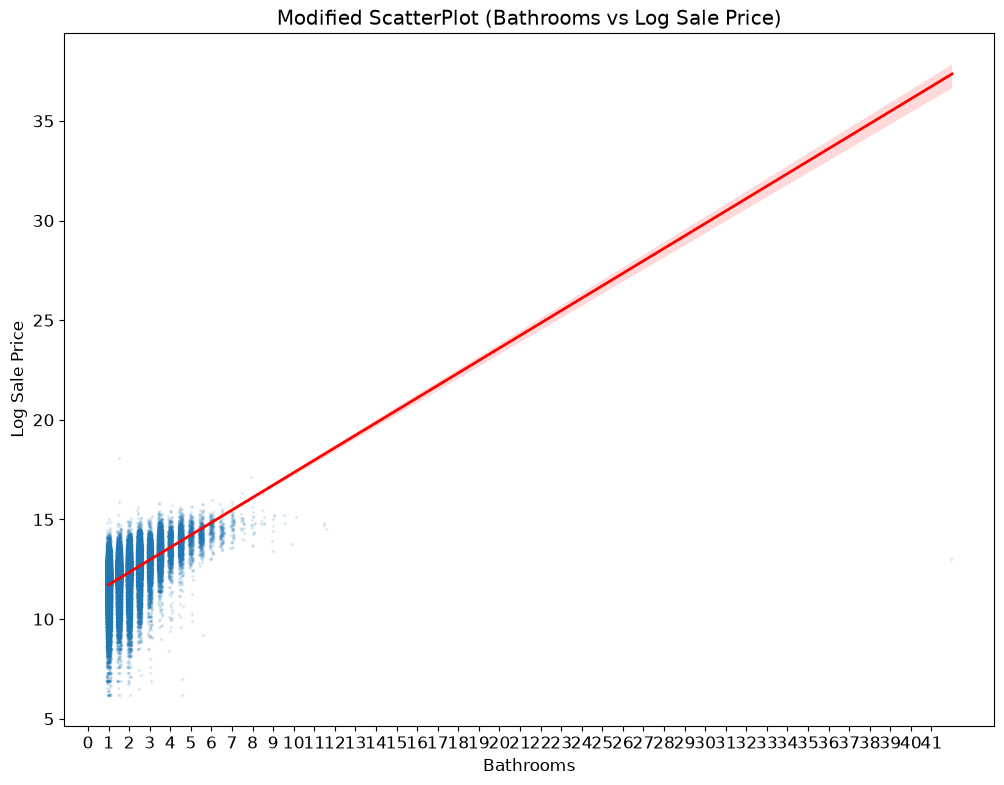

In [36]:
sns.regplot(
    data=training_data,
    x="Bathrooms",
    y="Log Sale Price",
    x_jitter=0.1,
    scatter_kws={"alpha":0.1, "s":2},
    line_kws={"color":"red", "lw":2}
)

plt.title("Modified ScatterPlot (Bathrooms vs Log Sale Price)")
plt.xlabel("Bathrooms")
plt.ylabel("Log Sale Price")
plt.xticks(range(int(training_data["Bathrooms"].max())))
plt.show()

<!-- END QUESTION -->

Now, let's take a look at the relationship between neighborhood and sale prices of the houses in the dataset.
Notice that currently we don't have the actual names for the neighborhoods. Instead we will use a similar column, `Neighborhood Code` (which is a numerical encoding of the actual neighborhoods by the Assessment office).

<br><br>

---
## Examine Neighborhood Code Feature

Before creating any visualization, let's quickly inspect how many different neighborhoods we are dealing with.

Assign the variable `num_neighborhoods` to the total number of unique neighborhoods in `training_data`. 


In [37]:
num_neighborhoods = training_data["Neighborhood Code"].nunique()
num_neighborhoods

193

<br><br>

---
## 🚀 Distribution of Log Sale Price for Each Neighborhood

If we try directly plotting the distribution of `Log Sale Price` for all of the households in each neighborhood using the `plot_categorical` function from the next cell, we get the following visualization.


![overplot](images/q5p2_catplot.png)


In [38]:
def plot_categorical(neighborhoods):
    fig, axs = plt.subplots(nrows=2)

    sns.boxplot(
        x='Neighborhood Code',
        y='Log Sale Price',
        data=neighborhoods,
        ax=axs[0],
    )

    sns.countplot(
        x='Neighborhood Code',
        data=neighborhoods,
        ax=axs[1],
    )

    # Draw median price
    axs[0].axhline(
        y=training_data['Log Sale Price'].median(), 
        color='red',
        linestyle='dotted'
    )

    # Label the bars with counts
    for patch in axs[1].patches:
        x = patch.get_bbox().get_points()[:, 0]
        y = patch.get_bbox().get_points()[1, 1]
        axs[1].annotate(f'{int(y)}', (x.mean(), y), ha='center', va='bottom')

    # Format x-axes
    axs[1].set_xticklabels(axs[1].xaxis.get_majorticklabels(), rotation=90)
    axs[0].xaxis.set_visible(False)

    # Narrow the gap between the plots
    plt.subplots_adjust(hspace=0.01)

we have run into the problem of overplotting again. 

The graph is overplotted because **there are actually quite a few neighborhoods in our dataset**! For the clarity of our visualization, we will have to zoom in again on a few of them. The reason for this is our visualization will become quite cluttered with a super dense x-axis.

Assign the variable `in_top_10_neighborhoods` to a copy of `training_data` that has been filtered to only contain rows corresponding to properties that are in one of the top 10 most popular neighborhoods. We define the top 10 most popular neighborhoods as being the 10 neighborhood codes that have the greatest number of property sales within them.

In [39]:
top_10_neighborhood_codes = training_data["Neighborhood Code"].value_counts().index[:10].to_list()
in_top_10_neighborhoods = training_data[training_data["Neighborhood Code"].isin(top_10_neighborhood_codes)]

Let's create another of the distribution of sale price within in each neighborhood again, but this time with a narrower focus!

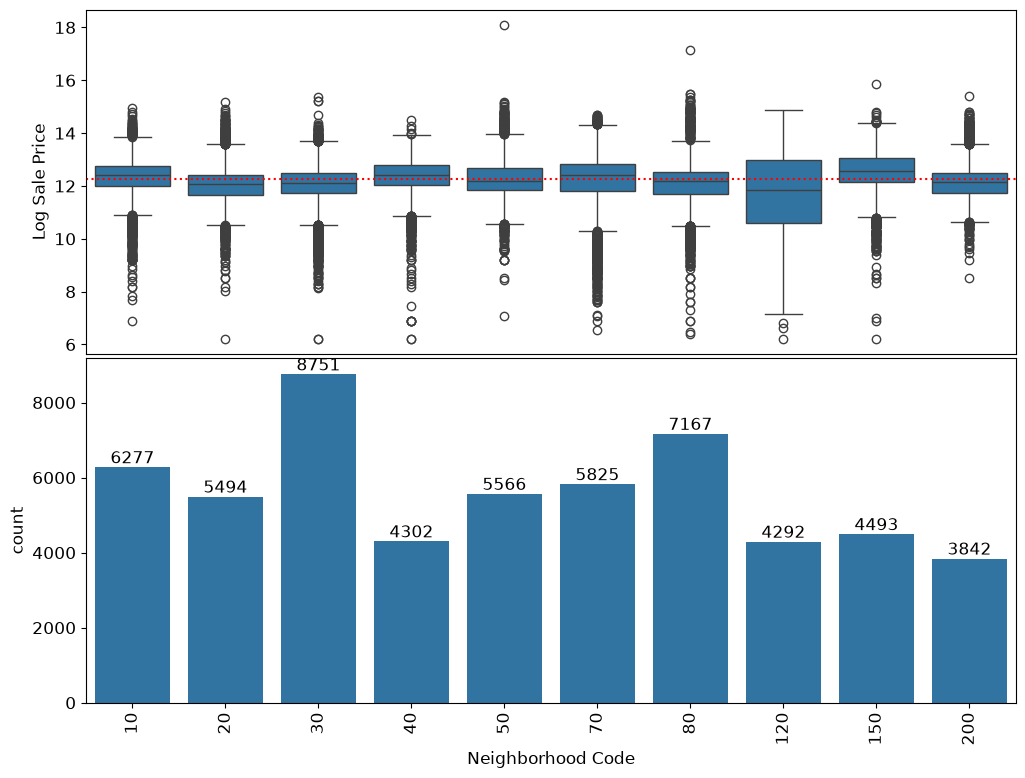

In [40]:
plot_categorical(neighborhoods=in_top_10_neighborhoods)

<br><br>

---
## 🚀 Bin Neighborhoods to Resolve Sparsity

From the plot above, we can see that there is much less data available for some neighborhoods. For example, Neighborhood 71 has only around 27% of the number of datapoints as Neighborhood 30.

One way we can deal with the lack of data from some neighborhoods is to create a new feature that bins neighborhoods together. We’ll categorize our neighborhoods in a crude way. In this question, we’ll compute how “expensive” each neighborhood is by aggregating the `Log Sale Price`s for all properties in a particular neighborhood using a `metric`, such as the median. We’ll use this `metric` to find the top `n` most expensive neighborhoods. Then, in the next section, we’ll label these “expensive neighborhoods” and leave all other neighborhoods unmarked.

Fill in `find_expensive_neighborhoods` to return a **list** of the neighborhood codes of the **top `n`** most expensive neighborhoods as measured by the choice of aggregating function, `metric`.

For example, calling `find_expensive_neighborhoods(training_data, n=3, metric=np.median)` should return the 3 neighborhood codes with the highest median `Log Sale Price` computed across all properties in those neighborhood codes. 

In [41]:
def find_expensive_neighborhoods(data, n=3, metric=np.median):
    """
    Input:
      data (DataFrame): should contain at least an int-valued 'Neighborhood Code'
        and a numeric 'Log Sale Price' column
      n (int): the number of top values desired
      metric (function): function used for aggregating the data in each neighborhood.
        for example, np.median for median prices
    
    Output:
      a list of the the neighborhood codes of the top n highest-priced neighborhoods 
      as measured by the metric function
    """
    neighborhoods = data.groupby("Neighborhood Code")["Log Sale Price"].agg(metric).sort_values(ascending=False).index[:n].to_list()
    
    # This makes sure the final list contains the generic int type used in Python3, not specific ones used in NumPy.
    return [int(code) for code in neighborhoods]

expensive_neighborhoods = find_expensive_neighborhoods(training_data, 3, np.median)
expensive_neighborhoods

[44, 94, 93]

<br><br>

---

We now have a list of neighborhoods we've deemed as higher-priced than others.  Let's use that information to write an additional function `add_in_expensive_neighborhood` that takes in a `DataFrame` of housing data (`data`) and a list of neighborhood codes considered to be expensive (`expensive_neighborhoods`). You can think of `expensive_neighborhoods` as being the output of the function `find_expensive_neighborhoods` from previous section. 

Using these inputs, `add_in_expensive_neighborhood` should add a column to `data` named `in_expensive_neighborhood` that takes on the **integer** value of 1 if a property is part of a neighborhood in `expensive_neighborhoods` and the integer value of 0 if it is not. This type of variable is known as an **indicator variable**.

In [42]:
def add_in_expensive_neighborhood(data, expensive_neighborhoods):
    """
    Input:
      data (DataFrame): a DataFrame containing a 'Neighborhood Code' column with values
        found in the codebook
      expensive_neighborhoods (list of ints): ints should be the neighborhood codes of
        neighborhoods pre-identified as expensive
    Output:
      DataFrame identical to the input with the addition of a binary
      in_expensive_neighborhood column
    """
    data['in_expensive_neighborhood'] = data["Neighborhood Code"].isin(expensive_neighborhoods).astype(int)
    return data

expensive_neighborhoods = find_expensive_neighborhoods(training_data, 3, np.median)
training_data = add_in_expensive_neighborhood(training_data, expensive_neighborhoods)

In the following question, we will take a closer look at the `Wall Material` feature of the dataset and examine how we can incorporate categorical features into the linear model.

<br><br>

---
## Hot-Encoding Categorical Features

From the `codebook.txt`, we observe that the Assessor's Office uses the following mapping for the numerical values in the `Wall Material` column.
```
Other Heating (Nominal): 

       1    Wood
       2    Masonry
       3    Wood&Masonry
       4    Stucco

```

The helper function `substitute_wall_material` replaces each numerical value in `Wall Material` with their corresponding heating source. This function returns a new `DataFrame`, not modify the existing `DataFrame`. 

In [43]:
def substitute_wall_material(data):
    """
    Input:
      data (DataFrame): a DataFrame containing a 'Wall Material' column.  Its values
                         should be limited to those found in the codebook
    Output:
      new DataFrame identical to the input except with a refactored 'Wall Material' column
    """
    new_data = data.copy()
    new_data["Wall Material"] = new_data["Wall Material"].replace({1: "Wood", 2: "Masonry", 3: "Wood&Masonry", 4: "Stucco"})
    return new_data
    
training_data_mapped = substitute_wall_material(training_data)
training_data_mapped.head()

,PIN,Property Class,Neighborhood Code,Land Square Feet,Town Code,Apartments,Wall Material,Roof Material,Basement,Basement Finish,...,Pure Market Filter,Garage Indicator,Neigborhood Code (mapping),Town and Neighborhood,Description,Lot Size,Log Sale Price,Log Building Square Feet,Bathrooms,in_expensive_neighborhood
1,13272240180000,202,120,3780.0,71,0.0,Masonry,1.0,1.0,1.0,...,1,1.0,120,71120,"This property, sold on 05/23/2018, is a one-st...",3780.0,12.560244,6.904751,1.0,0
2,25221150230000,202,210,4375.0,70,0.0,Masonry,1.0,2.0,3.0,...,1,1.0,210,70210,"This property, sold on 02/18/2016, is a one-st...",4375.0,9.998798,6.810142,1.0,0
3,10251130030000,203,220,4375.0,17,0.0,Wood&Masonry,1.0,1.0,3.0,...,1,1.0,220,17220,"This property, sold on 07/23/2013, is a one-st...",4375.0,12.323856,7.068172,1.5,0
4,31361040550000,202,120,8400.0,32,0.0,Wood&Masonry,1.0,2.0,3.0,...,1,1.0,120,32120,"This property, sold on 06/10/2016, is a one-st...",8400.0,10.025705,6.855409,1.0,0
6,30314240080000,203,181,10890.0,37,0.0,Wood,1.0,1.0,3.0,...,1,1.0,181,37181,"This property, sold on 10/26/2017, is a one-st...",10890.0,11.512925,7.458186,1.5,0


<br><br>
#### An Important Note on One-Hot-Encoding 

Unfortunately, simply replacing the integers with the appropriate strings isn’t sufficient for using `Wall Material` in our model.  Since `Wall Material` is a categorical variable, we will have to one-hot-encode the data. 

The helper function `ohe_wall_material` returns a `DataFrame` with the new column one-hot-encoded on the wall material of the household. These new columns should have the form `Wall Material_MATERIAL`. 

Use `scikit-learn`’s `OneHotEncoder` to perform the one-hot-encoding. `OneHotEncoder` will automatically generate column names of the form `Wall Material_MATERIAL`. In this notebook, we wish to construct the one-hot-encoding columns **without removing any columns**.

In [44]:
from sklearn.preprocessing import OneHotEncoder

def ohe_wall_material(data):
    """
    One-hot-encodes wall material. New columns are of the form "Wall Material_MATERIAL".
    """
    cat = ["Wall Material"]
    
    oh_enc = OneHotEncoder()
    oh_enc.fit(data[cat])

    cat_data = oh_enc.transform(data[cat]).toarray()
    cat_df = pd.DataFrame(data=cat_data, columns=oh_enc.get_feature_names_out(), index=data.index)    
    return data.join(cat_df)

training_data_ohe = ohe_wall_material(training_data_mapped)
# This line of code will display only the one-hot-encoded columns in training_data_ohe that 
# have names that begin with “Wall Material_" 
training_data_ohe.filter(regex='^Wall Material_').head(10)

,Wall Material_Masonry,Wall Material_Stucco,Wall Material_Wood,Wall Material_Wood&Masonry
1,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,1.0
6,0.0,0.0,1.0,0.0
7,0.0,0.0,1.0,0.0
8,1.0,0.0,0.0,0.0
9,0.0,0.0,1.0,0.0
10,0.0,0.0,1.0,0.0
11,1.0,0.0,0.0,0.0


Warming up for Project A2, let's discuss error metrics and designing our own custom error metric.

<!-- BEGIN QUESTION -->

<br><br>

---
## Design Error Metric to Resolve Unfairness
    
**SETUP**: RMSE is a very powerful error metric. However, RMSE is not the best choice when evaluating the *fairness* of a property appraisal system and can be quite limiting. In short, RMSE fails to inform about:

1. The distribution of the errors  
2. The sign (+/-) of the errors  
3. The relative size of the errors  

These aspects can be crucial when we are performing data analysis and developing a predictive model ourselves in this project. 

**TASK**: Design custom error metric that may outperform RMSE in some of the aspects above to build a better machine learning model. Later, in Project A2 we will apply this custom error metric and compare it against RMSE


1. **Define a mathematical formula** for  custom error metric that penalizes unfair predictions
2. **Explain your reasoning** for why this metric captures fairness better than standard metrics like MSE or MAE
3. **Identify a potential counterargument** against the custom error metric. Why it might not be ideal in this context?
    




**1. Define a mathematical formula** for  custom error metric that penalizes unfair predictions

- Let w1 = weight applied to 0.10th percentile (w1 > 1), w2 = weight applied to in between 10th and 90th percentile (w2 = 1), w3 = weight applied to above 0.90th percentile (w3 < 1).

- Note that the percentile was determined in a arbitrary manner to divide up into lower income group, middle income group, and higher income group. Based on formal standards on how to divide the income groups and the income distribution of the given data, the percentile number might be modified.

$$
I_1 = \{ i : y_i \le p_{0.1} \}
$$

$$
I_2 = \{ i : p_{0.1} < y_i < p_{0.9} \}
$$

$$
I_3 = \{ i : y_i \ge p_{0.9} \}
$$


$$
e_i = 
\begin{cases}
\hat{y}_i - y_i, & i \in I_1 \quad \text{(penalize overestimation in low-value homes)} \\
|y_i - \hat{y}_i|, & i \in I_2 \quad \text{(middle homes: magnitude only, no directional bias)} \\
y_i - \hat{y}_i, & i \in I_3 \quad \text{(penalize underestimation in high-value homes)}
\end{cases}
$$


$$
\text{Weighted Error} = 
\frac{1}{n} \Bigg[ 
w_1 \sum_{i \in I_1} e_i + 
w_2 \sum_{i \in I_2} e_i + 
w_3 \sum_{i \in I_3} e_i 
\Bigg]
$$

2. **Explain the reasoning** for why this metric captures fairness better than standard metrics like MSE or MAE

- The first part of the mathmatical model suggests there are more penalties for error occuring at the lower percentile (<= 0.10th percentile) and less penality occuring in the higher percentile (>= 0.90th percentile). Because MSE or MAE simply take the average sum of the errors (which is then squared or put absolute valued) for each of the data point, the loss function blindly focus on whether the error occurred more or less in general, rather than where the error occurred. 

- The second part of the mathmatical model is that the error is defined differently based on its location. Contextually, we are incentivizing underestimates for the lower percentile (lower income) and overestimates for the higher percentile (higher income). The reason for this framework once again brings up the rhetoric of fairness. The social cost of overestimating the lower income is more destructive. Similarly, the social cost of undersestimating the higher income is also destructive as the tax burden will fall back to the lower income.

- Overall my model captues the distribution, size, and, signs of error

3. **Identify a potential counterargument** against the custom error metric. Why it might not be ideal in this context?

- Some people might argue, if the model shifts it's focus the magnitude of the total error to distribution of the error, we have to the pay price of getting overall higher error, thus less "acurate model." 
- But we have to recall that the purpose of the model is fairnes, not just accuracy. Under the context of CCAO property assessment, the distribution of errors are crucial in understanding the model's fairness. Because, even the same size of error have different impacts based on the income level. If the error occured for the low-income people's range (lower quintile), then the error in overestimating the property value by $1000 may indicate the inability to pay the rent and potentially lose a house. However, if the same magnitude of error occured for the higher-income people's range (higher quintile), then the error in overestimating the property value by 1000 may indicate a cancellation of yatch vacation. 
- In other words, the disproportionate assignment of weights of errors based on where the error occured can actually create a fairer prediction.


<!-- END QUESTION -->

<br>

---

## Takeaways

In this project, we have...
- Peformed basic Exploratory Data Analysis (EDA)
- Added new features to the data
- Designed your own custom error metric

### What's next? 

In Project A2, we will focus on building a linear regression model to predict house prices. We are well-prepared to build such a model: we have considered what is in this dataset, what it can be used for, and engineered some features that should be useful for prediction. As we look into creating a house-pricing model for Cook County, we'll also consider some challenging social implications that this model may carry. 